# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

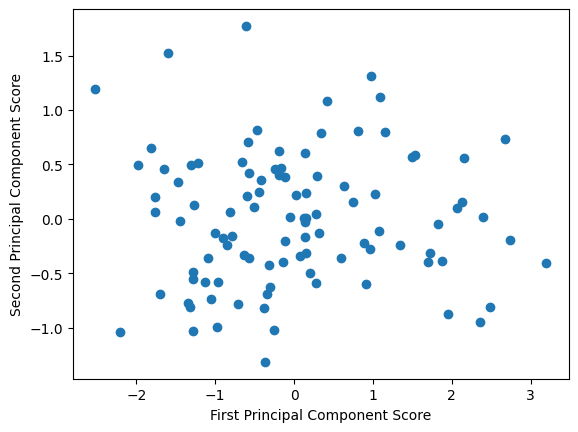

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

Those values in the top left corner have low values of PC1 and high values of PC2, suggesting they have a relatively low combined value of the original variable while also having a high contrast between variables. THis most likely reflects extreme values in series 3 or a large difference within series1 and 2. This plot overall is useful for identifying patterns and outliers but lacks interpretability of the original values. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
# Recall Brazil Cancer dataset in a way that i may commit changes to github

import os
import zipfile
import pandas as pd
import tempfile

# create temporary directory (not inside repo)
temp_dir = tempfile.gettempdir()
data_dir = os.path.join(temp_dir, "brazil_cancer_data")

os.makedirs(data_dir, exist_ok=True)

zip_path = os.path.join(data_dir, "cancer-data-brazil.zip")
csv_path = os.path.join(data_dir, "cancer_data_eng.csv")

# download if not already present
if not os.path.exists(csv_path):

    os.system(f"kaggle datasets download joaopedromedeiros/cancer-data-brazil -p {data_dir}")

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)

df = pd.read_csv(csv_path, encoding="ISO-8859-1")

print(df.head())

Dataset URL: https://www.kaggle.com/datasets/joaopedromedeiros/cancer-data-brazil
License(s): CC0-1.0


100%|██████████| 60.1M/60.1M [00:00<00:00, 75.0MB/s]


/tmp/ipykernel_6254/3394368465.py:25: DtypeWarning: Columns (0: Date.of.Birth, 1: Raca.Color, 2: Nationality, 3: Naturality.State, 4: Naturality, 5: Degree.of.Education, 6: State.Civil, 7: Status.Address, 8: City.Address, 9: Youth.Adult.Illness.Description, 10: Code.of.Disease.Adult.Young., 11: Indicator.of.Rare.Case, 12: Extension, 13: Laterality, 14: Statement, 15: TNM, 16: Status.Vital, 17: Type.of.Death, 18: Date.of.Death, 19: Date.of.Last.Contact, 20: Date.of.Diagnostic, 21: Distant.metastasis) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="ISO-8859-1")


   Patient.Code              RCBP.Name     Gender Date.of.Birth   Age  \
0      672054.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1975-03-16  30.0   
1      673213.0  RCBP CAMPINAS-UNICAMP   FEMININO    1950-05-24  53.0   
2      673396.0  RCBP CAMPINAS-UNICAMP   FEMININO    1951-09-02  51.0   
3      673425.0  RCBP CAMPINAS-UNICAMP   FEMININO    1929-11-21  73.0   
4      673745.0  RCBP CAMPINAS-UNICAMP  MASCULINO    1934-07-03  71.0   

  Raca.Color Nationality Naturality.State Naturality Degree.of.Education  ...  \
0     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   
1        NaN         NaN              NaN        NaN                 NaN  ...   
2      PARDA      BRASIL        SÃO PAULO        NaN                 NaN  ...   
3        NaN         NaN              NaN        NaN                 NaN  ...   
4     BRANCO      BRASIL        SÃO PAULO        NaN                 NaN  ...   

  Laterality  Statement  TNM Status.Vital Type.of.Death Date.of.Death  \
0

In [4]:
#Recall Data Cleaning Efforts

df["Date.of.Birth"] = pd.to_datetime(df["Date.of.Birth"], errors="coerce")
df["Date.of.Diagnostic"] = pd.to_datetime(df["Date.of.Diagnostic"], errors="coerce")

df.loc[df["Age"] >= 116, "Age"] = None
df.loc[df["Age"] <= 0, "Age"] = None


df.loc[
    df["Date.of.Birth"].isna() & df["Age"].notna(),
    "Date.of.Birth"
] = df["Date.of.Diagnostic"] - pd.to_timedelta(df["Age"] * 365.25, unit="D")

df[["Age", "Date.of.Birth"]].isnull().sum()

columns_encode = [
    "Gender",
    "Raca.Color",
    "Nationality",
    "Degree.of.Education",
    "State.Civil",
    "Status.Address",
    "Indicator.of.Rare.Case",
    "Diagnostic.means",
    "Extension",
    "Laterality",
    "Statement",
    "Status.Vital",
    "Type.of.Death",
]

df_encoded = pd.get_dummies(df, columns=columns_encode, drop_first=True)

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

numeric_cols, categorical_cols

/tmp/ipykernel_6254/283104828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns


(Index(['Patient.Code', 'Age', 'Code.Profession', 'Code.of.Morphology', 'year'], dtype='str'),
 Index(['RCBP.Name', 'Gender', 'Raca.Color', 'Nationality', 'Naturality.State',
        'Naturality', 'Degree.of.Education', 'State.Civil', 'Name.Occupation',
        'Status.Address', 'City.Address', 'Description.of.Topography',
        'Topography.Code', 'Morphology.Description', 'Description.of.Disease',
        'Illness.Code', 'Child.Illness.Description', 'Child.Illness.Code',
        'Youth.Adult.Illness.Description', 'Code.of.Disease.Adult.Young.',
        'Indicator.of.Rare.Case', 'Diagnostic.means', 'Extension', 'Laterality',
        'Statement', 'TNM', 'Status.Vital', 'Type.of.Death', 'Date.of.Death',
        'Date.of.Last.Contact', 'Distant.metastasis'],
       dtype='str'))

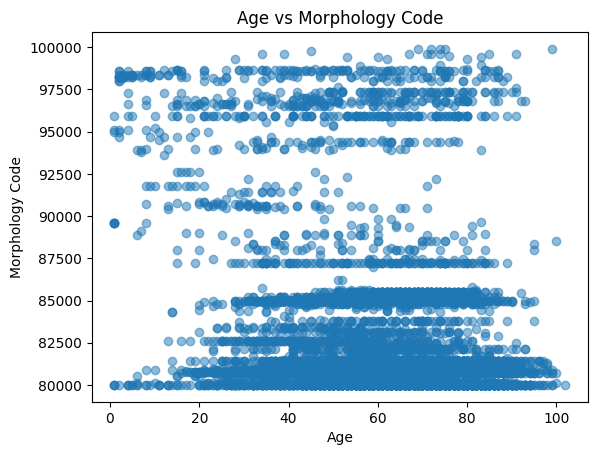

In [8]:
df_sample = df.sample(10000, random_state=42)

plt.figure()

plt.scatter(
    df_sample["Age"],
    df_sample["Code.of.Morphology"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Morphology Code")
plt.title("Age vs Morphology Code")
plt.show()

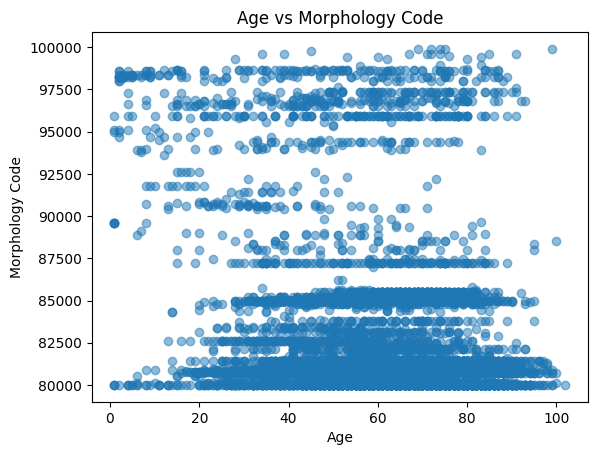

In [9]:
df_sample = df.sample(10000, random_state=42)

plt.figure()

plt.scatter(
    df_sample["Age"],
    df_sample["Code.of.Morphology"],
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("Morphology Code")
plt.title("Age vs Morphology Code")
plt.show()

#No Super Strong age dependency in this dataset. 

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df_encoded.select_dtypes(include=["int64", "float64"]).dropna()

X = X.iloc[:, :50]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

print("PC1 variance:", explained_variance[0])
print("PC1 + PC2 variance:", explained_variance[:2].sum())

PC1 variance: 0.3560262325972624
PC1 + PC2 variance: 0.5993495190524512


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


data = df_encoded.select_dtypes(include=["int64", "float64"])

# Drop all rows with missing values for this purpose
data = data.dropna()

X = data.drop(columns=["Age"])
y = data["Age"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("R^2:", model.score(X_test, y_test))

#Very weak predictive performance of age

R^2: 0.04852628534479109


In [12]:
import numpy as np

numeric_df = df_sample.select_dtypes(include=["int64","float64"])

z_scores = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())

outliers = (z_scores > 3).sum()
print(outliers.sort_values(ascending=False))

Code.of.Morphology    579
Code.Profession       278
Age                    74
Patient.Code            0
year                    0
dtype: int64


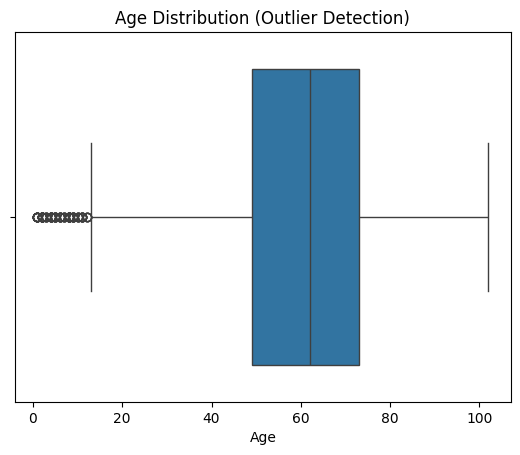

In [14]:
import seaborn as sns

plt.figure()
sns.boxplot(x=df_sample["Age"])
plt.title("Age Distribution (Outlier Detection)")
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

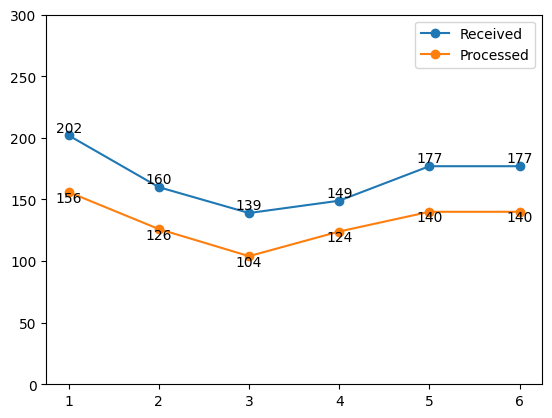

In [15]:

x = [1, 2, 3, 4, 5, 6]
received = [202, 160, 139, 149, 177, 177]
processed = [156, 126, 104, 124, 140, 140]

plt.plot(x, received, 'o-', label='Received')
plt.plot(x, processed, 'o-', label='Processed')

for i in range(len(x)):
    plt.text(x[i], received[i]+3, str(received[i]), ha='center')
    plt.text(x[i], processed[i]-8, str(processed[i]), ha='center')

plt.ylim(0, 300)
plt.legend()
plt.show()